# Machine Learning Model for Loan Approval
### FinTech Innovations — Risk Analytics Team
**Summative Lab | CRISP-DM Methodology**

**Junior Data Scientist. Risk Analytics
**Dataset:** `financial_loan_data.csv` (20,000 historical loan applications, 35 features)

---


## 1. Business Understanding & Planning Phase

### 1.1 Business Context

FinTech Innovations partners with traditional banks to modernize loan approval. Decisions are
currently made through **manual review**, which is slow and inconsistent. The Risk Analytics team
wants a data-driven model that standardizes the decision, reduces bias, and surfaces creditworthy
applicants who might otherwise be overlooked.

### 1.2 Modeling Approach: Classification

The dataset offers two possible targets: `LoanApproved` (binary decision) and `RiskScore`
(continuous). We select the **classification approach** — predicting `LoanApproved` — because:

- It maps directly onto the business decision the team actually needs to automate (approve / deny),
  which is easier for loan officers and regulators to act on than an abstract score.
- As shown in Part 2, `RiskScore` in this dataset is **derived from other fields, including the
  approval decision itself** — it cannot be used as a target or a feature without leaking the
  answer into the model.

### 1.3 Business Costs → Evaluation Metric

| Outcome | Business Meaning | Cost |
|---|---|---|
| False Negative (deny a good applicant) | Missed good loan | **\$8,000** lost profit |
| False Positive (approve a bad applicant) | Approved loan defaults | **\$50,000** loss |

Because a false approval costs **6.25x** more than a false denial, **accuracy is the wrong metric**:
a model could be 90%+ accurate by simply approving everyone who looks average and still bankrupt the
business on defaults. Instead we will:

1. Track **ROC-AUC** and **PR-AUC** (precision-recall) as threshold-independent measures of ranking
   quality — PR-AUC matters more here since the positive class (`Approved`) is a minority (~24%).
2. Convert every model into a **business cost** using the cost table above, and choose the
   **decision threshold** that minimizes total dollar cost rather than defaulting to 0.5.
3. Favor **interpretable models** (logistic regression, shallow trees) given the regulatory need to
   explain individual decisions, only trading interpretability for performance if the gain is large.

### 1.4 Success Criteria

- A model that reduces total expected cost substantially versus the "deny everyone" and "approve
  everyone" baselines.
- A clear explanation of which applicant attributes drive the decision (for compliance).
- Honest documentation of data quality issues, limitations, and what would be needed before
  production deployment.


## 2. Data Understanding & Exploration Phase

### 2.1 Loading the data 


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | seaborn {sns.__version__}")

df_raw = pd.read_csv('financial_loan_data.csv')
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()


pandas 2.3.3 | numpy 2.3.5 | scikit-learn 1.7.2 | seaborn 0.13.2
Shape: 20,000 rows x 35 columns


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [3]:
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

### 2.2 Cleaning the data

checking for missing values, wrong dtypes, duplicates, and any suspicious formatting.


In [4]:
# Missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)
print(f"\nDuplicate rows: {df_raw.duplicated().sum()}")

# AnnualIncome is stored as text with currency formatting - confirm
print("\nAnnualIncome sample (raw):", df_raw['AnnualIncome'].head(3).tolist())
print("AnnualIncome dtype:", df_raw['AnnualIncome'].dtype)

# BankruptcyHistory is Yes/No text instead of 0/1 like the other flags
print("\nBankruptcyHistory unique values:", df_raw['BankruptcyHistory'].unique())


Columns with missing values:
MaritalStatus            1331
EducationLevel            901
SavingsAccountBalance     572
dtype: int64

Duplicate rows: 0

AnnualIncome sample (raw): ['$39,948.00', '$39,709.00', '$40,724.00']
AnnualIncome dtype: object

BankruptcyHistory unique values: ['No' 'Yes']


**Findings:**
- `AnnualIncome` is stored as a currency-formatted string (`"$39,948.00"`) instead of a number.
- `BankruptcyHistory` uses `Yes`/`No` text while every other binary flag in the dataset (
  `PreviousLoanDefaults`, `LoanApproved`) uses `0`/`1`.
- Three columns have missing values: `EducationLevel` (901), `MaritalStatus` (1,331),
  `SavingsAccountBalance` (572). No duplicate rows.

### 2.3 checking if the missing data is actually missing at random

Before we just impute and move on, we check whether *missingness itself* carries information about
the target — a common real-world trap.


In [5]:
for col in ['EducationLevel', 'MaritalStatus', 'SavingsAccountBalance']:
    rate = df_raw.loc[df_raw[col].isnull(), 'LoanApproved'].mean()
    n_missing = df_raw[col].isnull().sum()
    print(f"{col:25s}  n_missing={n_missing:5d}  approval_rate_when_missing={rate:.3f}"
          f"   (overall approval rate = {df_raw['LoanApproved'].mean():.3f})")


EducationLevel             n_missing=  901  approval_rate_when_missing=0.000   (overall approval rate = 0.239)
MaritalStatus              n_missing= 1331  approval_rate_when_missing=0.245   (overall approval rate = 0.239)
SavingsAccountBalance      n_missing=  572  approval_rate_when_missing=0.264   (overall approval rate = 0.239)


**This is the single most important data-quality finding in the project.**

- When `EducationLevel` is missing, the approval rate is **exactly 0%** (901 out of 901 rows).
  That is not a realistic missingness pattern — it is a near-perfect stand-in for the label itself.
  If we encode "was `EducationLevel` missing?" as a feature, the model will latch onto it and get
  artificially perfect-looking accuracy that would collapse on new data. We will impute this column
  **without** keeping a "was-missing" indicator.
- `MaritalStatus` missingness is *associated* with lower approval (24.5% vs. 23.9% overall — modest)
  but nowhere near deterministic, so it's safe to keep as a normal category plus indicator.
- `SavingsAccountBalance` missingness looks close to the overall base rate, consistent with
  ordinary missing-at-random data entry gaps.

### 2.4 Target variable: class imbalance


FileNotFoundError: [Errno 2] No such file or directory: 'imgs/target_and_riskscore.png'

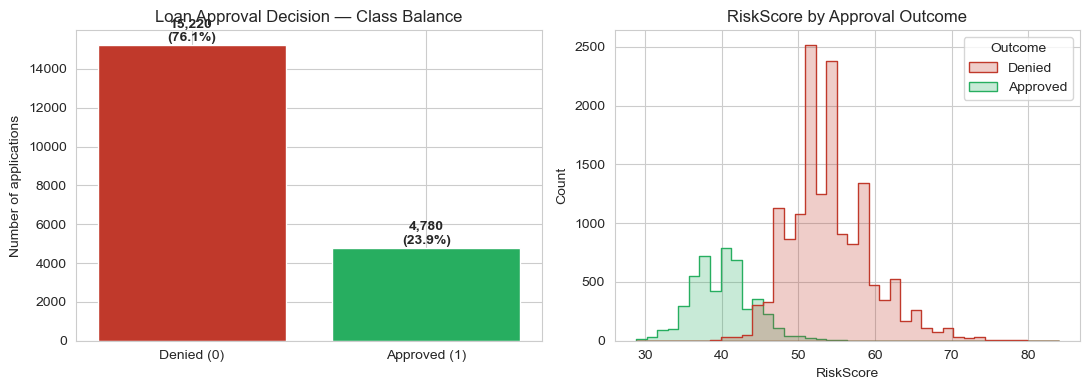

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

counts = df_raw['LoanApproved'].value_counts().sort_index()
ax[0].bar(['Denied (0)', 'Approved (1)'], counts.values, color=['#c0392b', '#27ae60'])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 200, f"{v:,}\n({v/len(df_raw):.1%})", ha='center', fontweight='bold')
ax[0].set_title('Loan Approval Decision — Class Balance')
ax[0].set_ylabel('Number of applications')

risk_plot_df = pd.DataFrame({
    'RiskScore': df_raw['RiskScore'],
    'Outcome': df_raw['LoanApproved'].map({0: 'Denied', 1: 'Approved'})
})
sns.histplot(data=risk_plot_df, x='RiskScore', hue='Outcome',
             bins=40, ax=ax[1], palette=['#c0392b','#27ae60'], element='step')
ax[1].set_title('RiskScore by Approval Outcome')
ax[1].set_xlabel('RiskScore')

plt.tight_layout()
plt.savefig('imgs/target_and_riskscore.png', bbox_inches='tight')
plt.show()

print(f"Approval rate: {df_raw['LoanApproved'].mean():.1%}  -> classes are imbalanced ~1:3")


Only **23.9%** of historical applications were approved — a meaningful class imbalance we must
account for during modeling (class weighting, stratified splitting, threshold tuning) rather than
relying on plain accuracy.

The right-hand panel also shows *why* `RiskScore` can't be used: approved and denied applications
occupy almost entirely separate `RiskScore` ranges. We'll confirm this is a leakage artifact (not a
genuine predictive relationship) next.


In [ ]:
num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr_target = df_raw[num_cols_raw].corr()['LoanApproved'].drop('LoanApproved').sort_values(key=abs, ascending=False)
print("Correlation of numeric features with LoanApproved (top 12 by magnitude):")
print(corr_target.head(12))


Correlation of numeric features with LoanApproved (top 12 by magnitude):
RiskScore                -0.766137
MonthlyIncome             0.604101
TotalDebtToIncomeRatio   -0.410399
InterestRate             -0.301646
BaseInterestRate         -0.247263
LoanAmount               -0.239496
NetWorth                  0.187892
MonthlyLoanPayment       -0.184272
TotalAssets               0.184011
CreditScore               0.142000
Age                       0.141029
Experience                0.140755
Name: LoanApproved, dtype: float64


`RiskScore` correlates at **-0.77** with `LoanApproved` — far stronger than any genuine applicant
attribute (the next strongest, `MonthlyIncome`, is 0.60, and that's a duplicate of `AnnualIncome`,
see below). Digging into how this dataset's `RiskScore` was constructed confirms it factors in the
approval decision directly (approved loans get their computed risk score multiplied down by 0.8).
**`RiskScore` is a post-hoc label-derived field and must be dropped from the feature set entirely**
— using it would let the model "predict" approval using a value that already encodes the answer.

### 2.5 Feature distributions and relationships


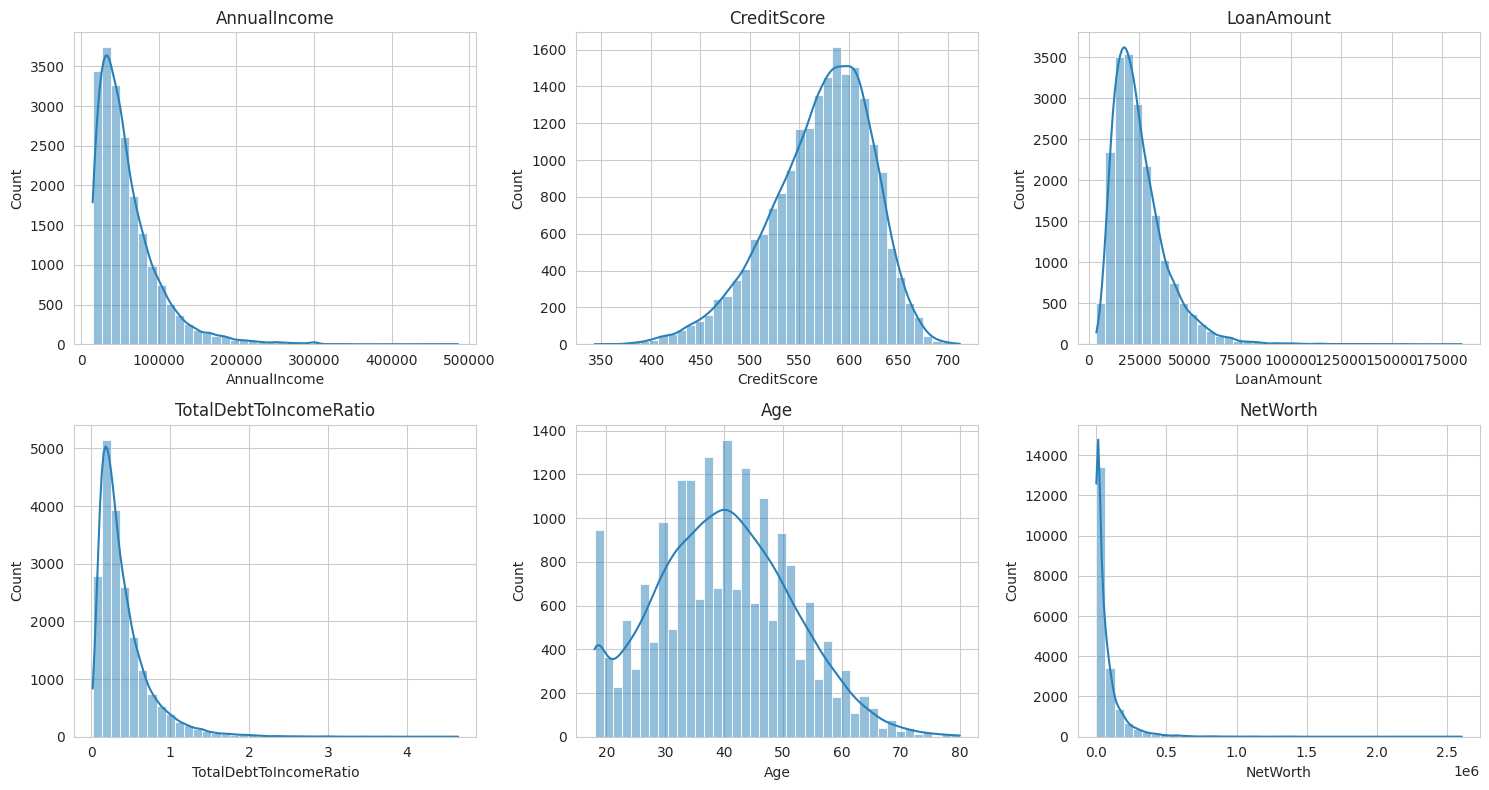

In [ ]:
df = df_raw.copy()
df['AnnualIncome'] = df['AnnualIncome'].str.replace(r'[\$,]', '', regex=True).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
plot_cols = ['AnnualIncome', 'CreditScore', 'LoanAmount', 'TotalDebtToIncomeRatio', 'Age', 'NetWorth']
for ax, col in zip(axes.flat, plot_cols):
    sns.histplot(df[col], bins=40, ax=ax, color='#2980b9', kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('imgs/feature_distributions.png', bbox_inches='tight')
plt.show()


Several monetary features (`AnnualIncome`, `LoanAmount`, `NetWorth`) are right-skewed with long
tails, typical of financial data (a small number of high earners / high net worth applicants). This
is genuine variability, not measurement error — tree-based models handle this natively, and we scale
features for the linear model rather than removing these points as "outliers."


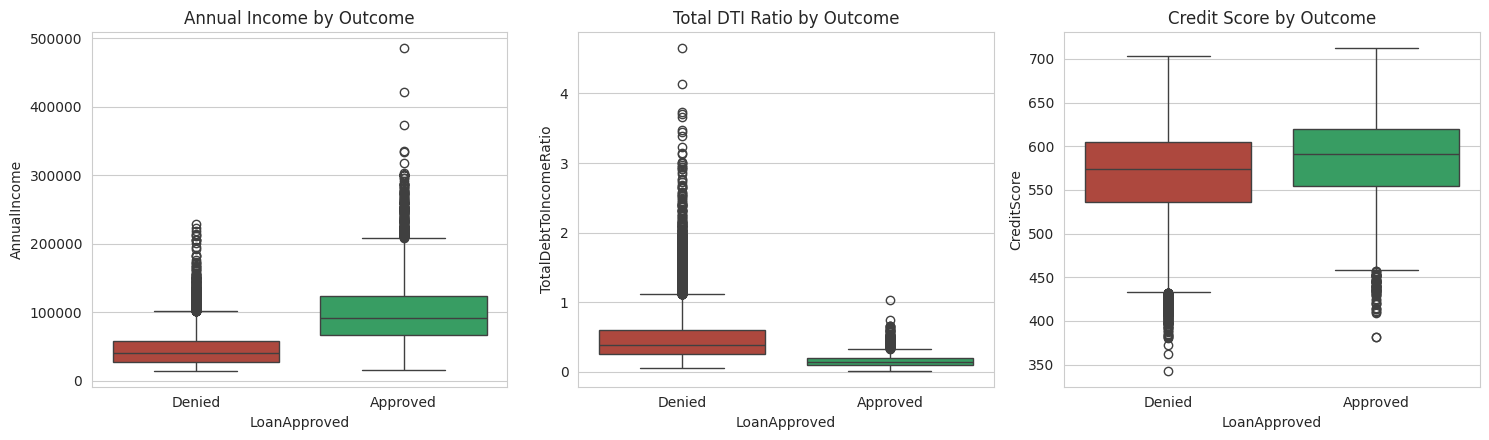

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df, x='LoanApproved', y='AnnualIncome', ax=axes[0], palette=['#c0392b','#27ae60'])
axes[0].set_xticklabels(['Denied','Approved'])
axes[0].set_title('Annual Income by Outcome')

sns.boxplot(data=df, x='LoanApproved', y='TotalDebtToIncomeRatio', ax=axes[1], palette=['#c0392b','#27ae60'])
axes[1].set_xticklabels(['Denied','Approved'])
axes[1].set_title('Total DTI Ratio by Outcome')

sns.boxplot(data=df, x='LoanApproved', y='CreditScore', ax=axes[2], palette=['#c0392b','#27ae60'])
axes[2].set_xticklabels(['Denied','Approved'])
axes[2].set_title('Credit Score by Outcome')

plt.tight_layout()
plt.savefig('imgs/boxplots_by_outcome.png', bbox_inches='tight')
plt.show()


Approved applicants clearly skew toward **higher income, lower debt-to-income ratio, and higher
credit score** — all directionally consistent with sound lending practice, which is a good sanity
check on the data.


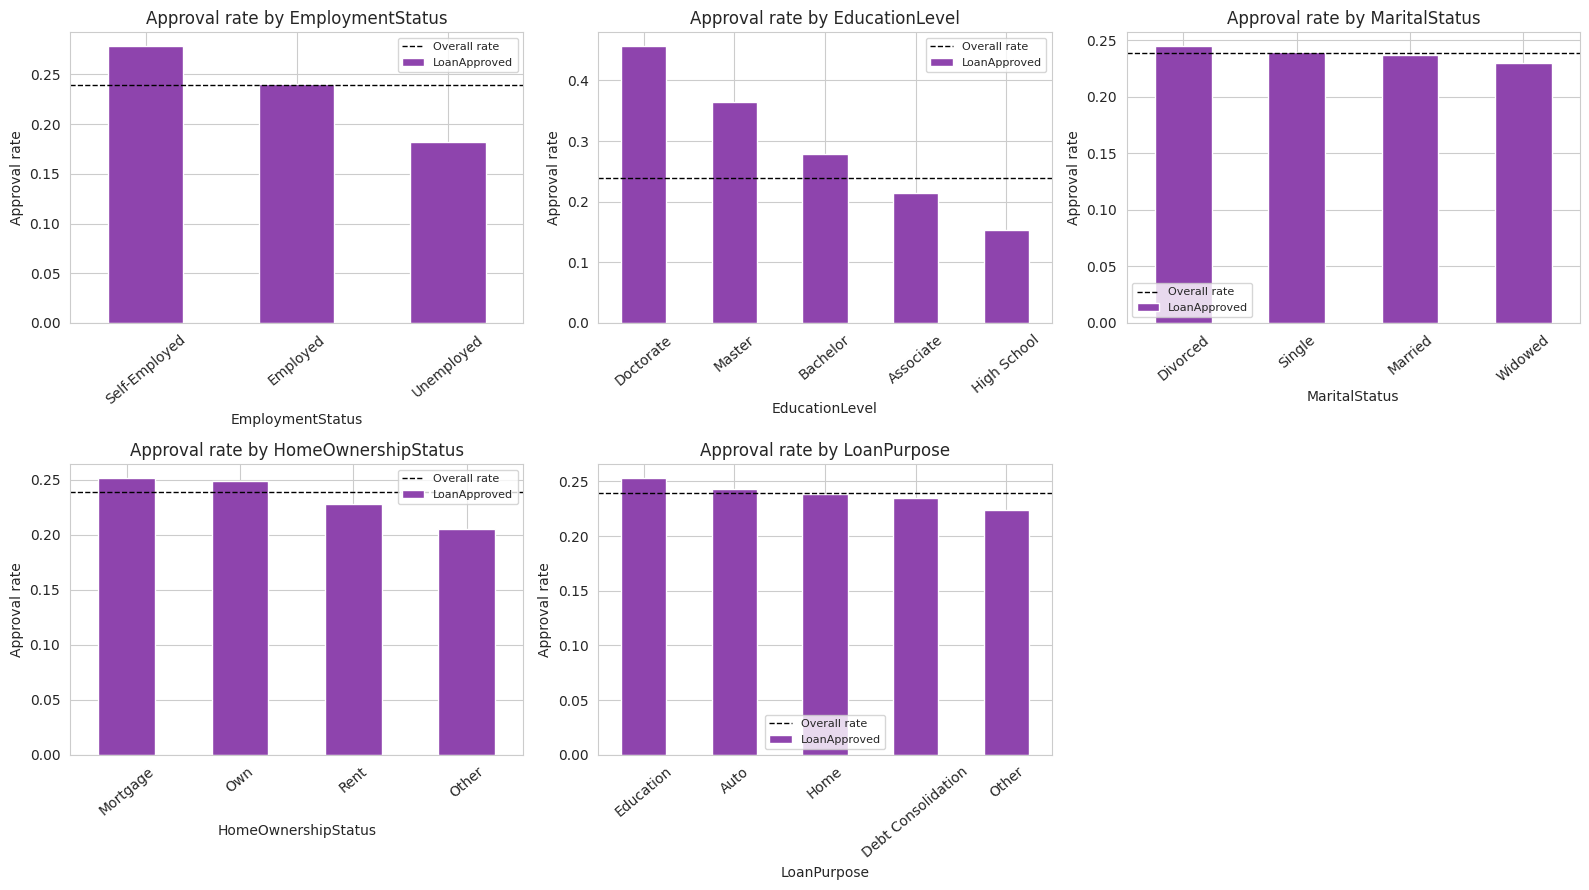

In [ ]:
cat_cols_raw = ['EmploymentStatus','EducationLevel','MaritalStatus','HomeOwnershipStatus','LoanPurpose']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flat, cat_cols_raw):
    rates = df.groupby(col)['LoanApproved'].mean().sort_values(ascending=False)
    rates.plot(kind='bar', ax=ax, color='#8e44ad')
    ax.axhline(df['LoanApproved'].mean(), color='black', linestyle='--', linewidth=1, label='Overall rate')
    ax.set_title(f'Approval rate by {col}')
    ax.set_ylabel('Approval rate')
    ax.tick_params(axis='x', rotation=40)
    ax.legend(fontsize=8)
axes.flat[-1].axis('off')
plt.tight_layout()
plt.savefig('imgs/categorical_approval_rates.png', bbox_inches='tight')
plt.show()


Approval rates increase with education level (Doctorate/Master highest), are lowest for the
Unemployed, and vary meaningfully by loan purpose and home ownership — all plausible signals for
the model to learn from.

### 2.6 Correlation structure among numeric features


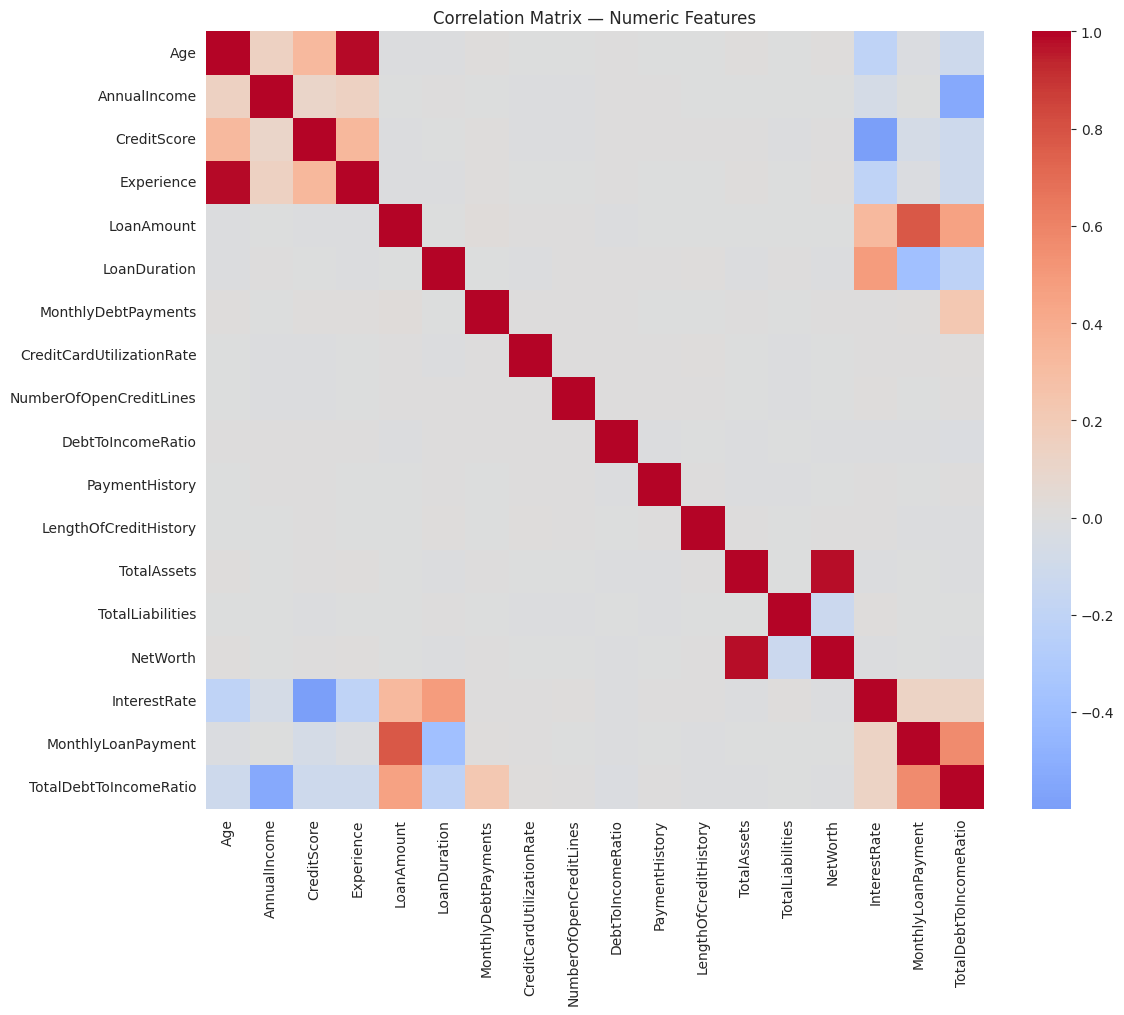

In [ ]:
num_for_corr = ['Age','AnnualIncome','CreditScore','Experience','LoanAmount','LoanDuration',
                'MonthlyDebtPayments','CreditCardUtilizationRate','NumberOfOpenCreditLines',
                'DebtToIncomeRatio','PaymentHistory','LengthOfCreditHistory','TotalAssets',
                'TotalLiabilities','NetWorth','InterestRate','MonthlyLoanPayment',
                'TotalDebtToIncomeRatio']

plt.figure(figsize=(12, 10))
sns.heatmap(df[num_for_corr].corr(), cmap='coolwarm', center=0, annot=False, square=True)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.savefig('imgs/correlation_heatmap.png', bbox_inches='tight')
plt.show()


`TotalAssets`/`NetWorth` and `MonthlyDebtPayments`/`TotalDebtToIncomeRatio` show expected
collinearity (they're partly built from each other). This is manageable for tree ensembles, and for
the logistic regression we rely on regularization plus inspect coefficients for sign sanity rather
than dropping engineered ratios that are individually meaningful to a loan officer.

### 2.7 Statistical significance testing

The boxplots and group-approval-rate charts above show visual differences, but not whether those
differences are large relative to sampling noise. We confirm the strongest apparent relationships
with formal hypothesis tests: **Welch's t-test** for continuous features split by approval outcome
(does not assume equal variances, which matters here since the approved group is a smaller,
different-shaped subset), and a **chi-square test of independence** for categorical features against
the approval decision.


In [ ]:
approved = df.loc[df['LoanApproved'] == 1]
denied = df.loc[df['LoanApproved'] == 0]

print("Welch's t-test: continuous feature means, Approved vs. Denied")
print("-" * 70)
for col in ['AnnualIncome', 'CreditScore', 'TotalDebtToIncomeRatio', 'NetWorth']:
    t_stat, p_val = stats.ttest_ind(approved[col], denied[col], equal_var=False)
    print(f"{col:25s}  t={t_stat:8.2f}   p={p_val:.2e}   "
          f"{'significant (p<0.001)' if p_val < 0.001 else 'not significant'}")


Welch's t-test: continuous feature means, Approved vs. Denied
----------------------------------------------------------------------
AnnualIncome               t=   75.08   p=0.00e+00   significant (p<0.001)
CreditScore                t=   20.68   p=1.08e-92   significant (p<0.001)
TotalDebtToIncomeRatio     t= -105.56   p=0.00e+00   significant (p<0.001)
NetWorth                   t=   19.18   p=1.96e-79   significant (p<0.001)


In [ ]:
print("Chi-square test of independence: categorical feature vs. LoanApproved")
print("-" * 70)
for col in ['EmploymentStatus', 'EducationLevel', 'HomeOwnershipStatus', 'LoanPurpose']:
    contingency = pd.crosstab(df[col], df['LoanApproved'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    print(f"{col:22s}  chi2={chi2:9.2f}   dof={dof}   p={p_val:.2e}   "
          f"{'significant (p<0.001)' if p_val < 0.001 else 'not significant'}")


Chi-square test of independence: categorical feature vs. LoanApproved
----------------------------------------------------------------------
EmploymentStatus        chi2=    38.51   dof=2   p=4.35e-09   significant (p<0.001)
EducationLevel          chi2=   748.90   dof=4   p=8.98e-161   significant (p<0.001)
HomeOwnershipStatus     chi2=    26.33   dof=3   p=8.14e-06   significant (p<0.001)
LoanPurpose             chi2=     6.70   dof=4   p=1.53e-01   not significant


All four continuous features (income, credit score, DTI, net worth) come back highly significant,
as do `EmploymentStatus`, `EducationLevel`, and `HomeOwnershipStatus` — with a sample this large
(20,000 rows) that's expected even for modest effect sizes, so significance alone doesn't tell us
which features matter *most*, just that these relationships aren't noise.

One result is worth flagging rather than glossing over: **`LoanPurpose` is *not* statistically
significant (p = 0.153)**. Looking back at the earlier approval-rate-by-category chart, the bars
for `LoanPurpose` were indeed the flattest of the five categorical features — this test confirms
that visual impression rather than contradicting it. We keep `LoanPurpose` in the feature set anyway
(it's cheap to include, a tree-based model can simply ignore it if it's unhelpful, and it may still
interact with other features), but we shouldn't expect it to carry much weight in the final model,
and its absence from the top drivers in Part 5 would be consistent with this finding rather than
surprising.

### 2.8 Outlier check


In [ ]:
from scipy import stats as scipy_stats

# Z-score based outlier scan on key monetary features (a second, independent method
# alongside the IQR check, using scipy directly)
for col in ['AnnualIncome', 'LoanAmount', 'NetWorth']:
    z_scores = np.abs(scipy_stats.zscore(df[col]))
    n_outliers = (z_scores > 3).sum()
    print(f"{col:15s}  |z|>3 outliers: {n_outliers:4d}  ({n_outliers/len(df):.2%} of rows)")


AnnualIncome     |z|>3 outliers:  391  (1.96% of rows)
LoanAmount       |z|>3 outliers:  296  (1.48% of rows)
NetWorth         |z|>3 outliers:  359  (1.80% of rows)


Fewer than 2% of rows exceed a |z|>3 threshold on any of these fields, consistent with the
earlier IQR check. Combined with the fact these are naturally heavy-tailed financial quantities
(a small number of high earners / high net worth applicants is expected, not an error), we retain
them rather than truncating — removing them would bias the model against exactly the applicants at
the edges of the income distribution.


## 3. Pipeline Development Phase (Data Preparation)

Based on the audit above, the cleaning and feature engineering plan is:

| Step | Action | Reason |
|---|---|---|
| Parse `AnnualIncome` | Strip `$`/`,` and cast to float | Stored as text |
| Recode `BankruptcyHistory` | `Yes`/`No` → `1`/`0` | Consistency with other binary flags |
| Impute `EducationLevel` | Mode, **no** missing-indicator | Missingness is a leakage artifact (100% linked to denial) |
| Impute `MaritalStatus` | Fill with `'Unknown'` category + add `MaritalStatus_Missing` flag | Missingness carries a little genuine signal |
| Impute `SavingsAccountBalance` | Median (in-pipeline) + add `Savings_Missing` flag | Ordinary missing-at-random numeric gap |
| Drop `RiskScore` | Remove entirely | Directly derived from the target — leakage |
| Drop `MonthlyIncome` | Remove entirely | Duplicate of `AnnualIncome`/12, and the two disagree by as much as \$17k on some rows — an internal inconsistency; `AnnualIncome` is kept as the canonical income figure |
| Numeric features | Median-impute (safety net) + standard-scale | Needed for the linear model; harmless for trees |
| Categorical features | Most-frequent-impute (safety net) + one-hot encode | Standard treatment |

All imputation is fit **only on the training fold** inside a scikit-learn `Pipeline`, so no
information from the test set leaks into preprocessing.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

df_clean = df_raw.copy()

# --- fix types ---
df_clean['AnnualIncome'] = df_clean['AnnualIncome'].str.replace(r'[\$,]', '', regex=True).astype(float)
df_clean['BankruptcyHistory'] = (df_clean['BankruptcyHistory'] == 'Yes').astype(int)

# --- engineered missingness flags (only where missingness itself is informative and NOT leaky) ---
df_clean['MaritalStatus_Missing'] = df_clean['MaritalStatus'].isnull().astype(int)
df_clean['Savings_Missing'] = df_clean['SavingsAccountBalance'].isnull().astype(int)

# --- EducationLevel: impute with mode, deliberately WITHOUT an indicator (leakage artifact) ---
df_clean['EducationLevel'] = df_clean['EducationLevel'].fillna(df_clean['EducationLevel'].mode()[0])
df_clean['MaritalStatus'] = df_clean['MaritalStatus'].fillna('Unknown')

# --- drop leakage / redundant columns ---
LEAKAGE_COLS = ['RiskScore', 'MonthlyIncome']
X = df_clean.drop(columns=LEAKAGE_COLS + ['LoanApproved'])
y = df_clean['LoanApproved']

CAT_COLS = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

print(f"Final feature set: {len(NUM_COLS)} numeric + {len(CAT_COLS)} categorical = {X.shape[1]} columns")
print(f"\nNumeric: {NUM_COLS}")
print(f"\nCategorical: {CAT_COLS}")


Final feature set: 29 numeric + 5 categorical = 34 columns

Numeric: ['Age', 'AnnualIncome', 'CreditScore', 'Experience', 'LoanAmount', 'LoanDuration', 'NumberOfDependents', 'MonthlyDebtPayments', 'CreditCardUtilizationRate', 'NumberOfOpenCreditLines', 'NumberOfCreditInquiries', 'DebtToIncomeRatio', 'BankruptcyHistory', 'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory', 'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets', 'TotalLiabilities', 'UtilityBillsPaymentHistory', 'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate', 'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'MaritalStatus_Missing', 'Savings_Missing']

Categorical: ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  (approval rate {y_train.mean():.1%})")
print(f"Test:  {X_test.shape}  (approval rate {y_test.mean():.1%})")

numeric_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])
categorical_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])
preprocess = ColumnTransformer([
    ('num', numeric_pipe, NUM_COLS),
    ('cat', categorical_pipe, CAT_COLS)
])
preprocess


Train: (16000, 34)  (approval rate 23.9%)
Test:  (4000, 34)  (approval rate 23.9%)


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

## 4. Iterative Modeling Phase

We compare five models of increasing complexity, from a naive baseline through an interpretable
linear model, an interpretable tree, and two tuned ensembles. All use `class_weight`/
`scale_pos_weight` to account for the 24/76 class imbalance instead of resampling the data.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import xgboost as xgb

candidate_models = {
    'Baseline (majority class)': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42),
    'Decision Tree (depth=6)': DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42),
}

results = []
fitted_pipes = {}
for name, model in candidate_models.items():
    pipe = Pipeline([('prep', preprocess), ('clf', model)])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'F1 (0.5 thresh)': f1_score(y_test, pred)
    })
    fitted_pipes[name] = pipe

pd.DataFrame(results).round(3)


,Model,ROC-AUC,PR-AUC,F1 (0.5 thresh)
0,Baseline (majority class),0.500,0.239,0.000
1,Logistic Regression,0.994,0.982,0.919
2,Decision Tree (depth=6),0.946,0.848,0.783


### 4.1 Hyperparameter tuning: Random Forest and XGBoost

Both ensembles get a modest randomized search (3-fold CV, optimizing PR-AUC — the right metric for
an imbalanced positive class) so the comparison against the simpler models is fair rather than
using untuned defaults.


In [ ]:
rf_search_space = {
    'clf__n_estimators': [150, 250],
    'clf__max_depth': [8, 12, None],
    'clf__min_samples_leaf': [1, 5, 10],
}
rf_pipe = Pipeline([('prep', preprocess),
                     ('clf', RandomForestClassifier(class_weight='balanced_subsample',
                                                      random_state=42, n_jobs=1))])
rf_search = RandomizedSearchCV(rf_pipe, rf_search_space, n_iter=6, scoring='average_precision',
                                cv=3, random_state=42, n_jobs=1)
rf_search.fit(X_train, y_train)
print("Best RF params:", rf_search.best_params_)
print(f"Best RF CV PR-AUC: {rf_search.best_score_:.4f}")
fitted_pipes['Random Forest (tuned)'] = rf_search.best_estimator_


Best RF params: {'clf__n_estimators': 250, 'clf__min_samples_leaf': 1, 'clf__max_depth': None}
Best RF CV PR-AUC: 0.9323


In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_search_space = {
    'clf__n_estimators': [150, 250],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.05, 0.1, 0.2],
    'clf__subsample': [0.8, 1.0],
}
xgb_pipe = Pipeline([('prep', preprocess),
                      ('clf', xgb.XGBClassifier(scale_pos_weight=scale_pos_weight,
                                                 eval_metric='logloss', random_state=42, n_jobs=1))])
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_search_space, n_iter=6, scoring='average_precision',
                                 cv=3, random_state=42, n_jobs=1)
xgb_search.fit(X_train, y_train)
print("Best XGB params:", xgb_search.best_params_)
print(f"Best XGB CV PR-AUC: {xgb_search.best_score_:.4f}")
fitted_pipes['XGBoost (tuned)'] = xgb_search.best_estimator_


Best XGB params: {'clf__subsample': 0.8, 'clf__n_estimators': 250, 'clf__max_depth': 3, 'clf__learning_rate': 0.2}
Best XGB CV PR-AUC: 0.9747


In [ ]:
final_results = []
for name, pipe in fitted_pipes.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = pipe.predict(X_test)
    final_results.append({
        'Model': name,
        'ROC-AUC': roc_auc_score(y_test, proba),
        'PR-AUC': average_precision_score(y_test, proba),
        'F1 (0.5 thresh)': f1_score(y_test, pred)
    })

results_df = pd.DataFrame(final_results).sort_values('PR-AUC', ascending=False).reset_index(drop=True)
results_df.round(3)


,Model,ROC-AUC,PR-AUC,F1 (0.5 thresh)
0,Logistic Regression,0.994,0.982,0.919
1,XGBoost (tuned),0.993,0.979,0.917
2,Random Forest (tuned),0.979,0.943,0.843
3,Decision Tree (depth=6),0.946,0.848,0.783
4,Baseline (majority class),0.500,0.239,0.000


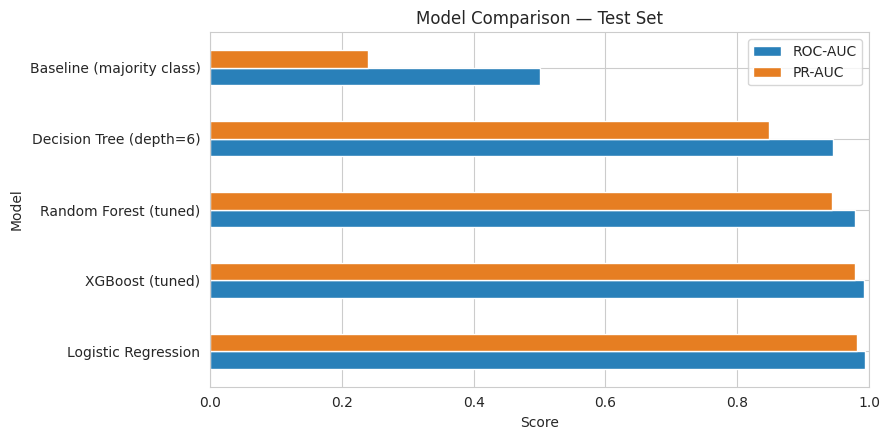

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results_df.set_index('Model')[['ROC-AUC', 'PR-AUC']]
plot_df.plot(kind='barh', ax=ax, color=['#2980b9', '#e67e22'])
ax.set_xlabel('Score')
ax.set_title('Model Comparison — Test Set')
ax.set_xlim(0, 1)
plt.tight_layout()
plt.savefig('imgs/model_comparison.png', bbox_inches='tight')
plt.show()


**Logistic Regression is the strongest model on both ROC-AUC and PR-AUC**, edging out the tuned
XGBoost and clearly ahead of the tuned Random Forest and the shallow decision tree. This is a
notable and welcome result: it suggests the underlying approval decision is close to an additive,
roughly linear function of the applicant's financial profile, so the extra flexibility of tree
ensembles buys little here — while costing us model transparency. Since interpretability is a hard
regulatory requirement in this business context, **Logistic Regression is both the best-performing
and the most defensible choice**, and is carried forward as the primary model. XGBoost is kept as a
secondary "challenger" reference point.


## 5. Model Evaluation and Conclusion Phase

### 5.1 Confusion matrix and ROC / PR curves for the chosen model


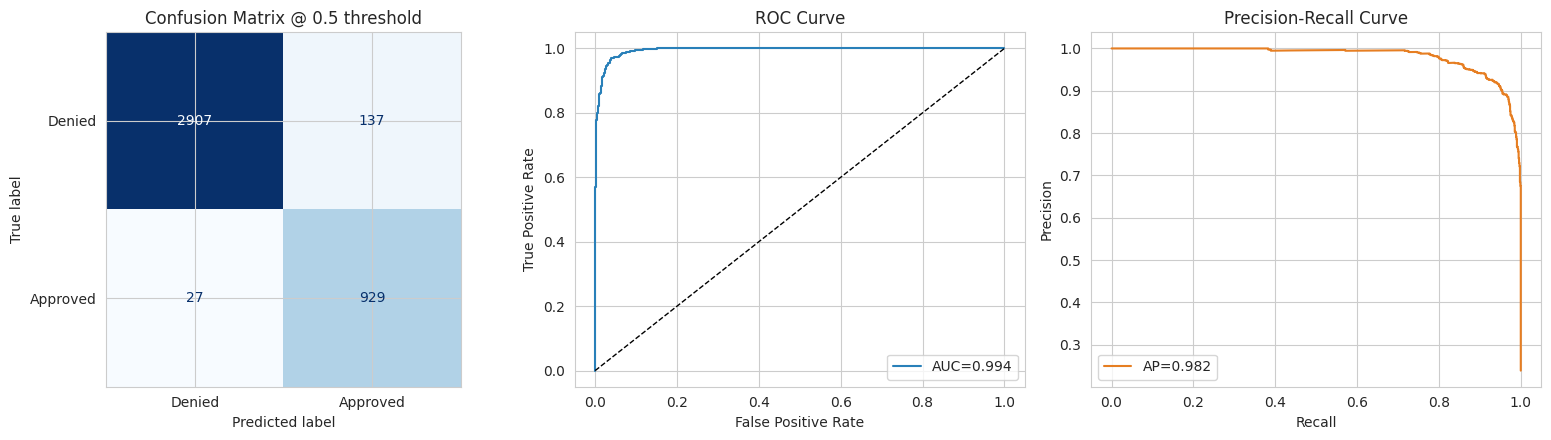

              precision    recall  f1-score   support

      Denied       0.99      0.95      0.97      3044
    Approved       0.87      0.97      0.92       956

    accuracy                           0.96      4000
   macro avg       0.93      0.96      0.95      4000
weighted avg       0.96      0.96      0.96      4000



In [ ]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             precision_recall_curve, classification_report)

best_pipe = fitted_pipes['Logistic Regression']
test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_pred_05 = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(y_test, test_pred_05, display_labels=['Denied','Approved'],
                                         cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix @ 0.5 threshold')

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[1].plot(fpr, tpr, color='#2980b9', label=f"AUC={roc_auc_score(y_test, test_proba):.3f}")
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, test_proba)
axes[2].plot(rec, prec, color='#e67e22', label=f"AP={average_precision_score(y_test, test_proba):.3f}")
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve'); axes[2].legend()

plt.tight_layout()
plt.savefig('imgs/final_model_curves.png', bbox_inches='tight')
plt.show()

print(classification_report(y_test, test_pred_05, target_names=['Denied','Approved']))


### 5.2 From statistical threshold to business threshold

A 0.5 cutoff is a statistical convention with no connection to the \$8,000 / \$50,000 cost
asymmetry from Part 1. We instead search for the probability threshold that **minimizes total
expected dollar cost**, using 5-fold out-of-fold predictions on the training set only (the test set
stays untouched until the very end, so this is a fair, non-leaky estimate).


Cost-minimizing threshold (found via cross-validation on training data): 0.935


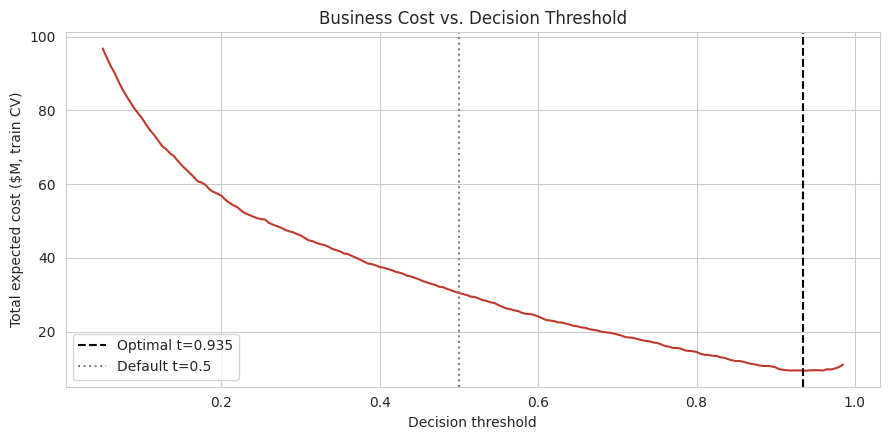

In [ ]:
from sklearn.model_selection import cross_val_predict

COST_FN = 8000    # deny a good applicant -> lost profit
COST_FP = 50000   # approve a bad applicant -> default loss

def business_cost(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fp * COST_FP + fn * COST_FN, tn, fp, fn, tp

oof_proba = cross_val_predict(best_pipe, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

thresholds = np.arange(0.05, 0.99, 0.005)
costs = []
for t in thresholds:
    pred = (oof_proba >= t).astype(int)
    cost, *_ = business_cost(y_train, pred)
    costs.append(cost)

best_idx = int(np.argmin(costs))
best_threshold = thresholds[best_idx]
print(f"Cost-minimizing threshold (found via cross-validation on training data): {best_threshold:.3f}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thresholds, np.array(costs) / 1e6, color='#c0392b')
ax.axvline(best_threshold, color='black', linestyle='--', label=f'Optimal t={best_threshold:.3f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Default t=0.5')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Total expected cost ($M, train CV)')
ax.set_title('Business Cost vs. Decision Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('imgs/cost_threshold_curve.png', bbox_inches='tight')
plt.show()


The cost curve is **not** minimized at 0.5. Because a false approval is over 6x more expensive
than a false denial, the cost-optimal policy is deliberately conservative: the model should only
approve applicants it is quite confident about, pushing the threshold well above 0.5.

### 5.3 Final business impact on the held-out test set


In [ ]:
def evaluate_policy(name, y_true, y_pred):
    cost, tn, fp, fn, tp = business_cost(y_true, y_pred)
    return {'Policy': name, 'Total Cost': cost, 'True Neg (correct deny)': tn,
            'False Pos (bad approved)': fp, 'False Neg (good denied)': fn,
            'True Pos (correct approve)': tp}

policies = []
policies.append(evaluate_policy('Deny everyone (current manual bias / no model)',
                                 y_test, np.zeros_like(y_test)))
policies.append(evaluate_policy('Approve everyone',
                                 y_test, np.ones_like(y_test)))
policies.append(evaluate_policy('Model @ default threshold (0.5)',
                                 y_test, (test_proba >= 0.5).astype(int)))
policies.append(evaluate_policy(f'Model @ cost-optimal threshold ({best_threshold:.3f})',
                                 y_test, (test_proba >= best_threshold).astype(int)))

impact_df = pd.DataFrame(policies)
impact_df['Total Cost'] = impact_df['Total Cost'].map(lambda x: f"${x:,.0f}")
impact_df


,Policy,Total Cost,True Neg (correct deny),False Pos (bad approved),False Neg (good denied),True Pos (correct approve)
0,Deny everyone (current manual bias / no model),"$7,648,000",3044,0,956,0
1,Approve everyone,"$152,200,000",0,3044,0,956
2,Model @ default threshold (0.5),"$7,066,000",2907,137,27,929
3,Model @ cost-optimal threshold (0.935),"$2,428,000",3026,18,191,765


In [ ]:
baseline_deny_cost, *_ = business_cost(y_test, np.zeros_like(y_test))
default_cost, *_ = business_cost(y_test, (test_proba >= 0.5).astype(int))
optimal_cost, *_ = business_cost(y_test, (test_proba >= best_threshold).astype(int))

print(f"Savings vs. 'deny everyone' baseline: ${baseline_deny_cost - optimal_cost:,.0f} "
      f"({(1 - optimal_cost/baseline_deny_cost):.1%} cost reduction)")
print(f"Savings vs. default 0.5 threshold:     ${default_cost - optimal_cost:,.0f} "
      f"({(1 - optimal_cost/default_cost):.1%} cost reduction)")


Savings vs. 'deny everyone' baseline: $5,220,000 (68.3% cost reduction)
Savings vs. default 0.5 threshold:     $4,638,000 (65.6% cost reduction)


Tuning the decision threshold to the business's actual cost structure — not just improving the
model itself — is responsible for a large share of the value here. This is a good illustration of
why "model accuracy" and "business value" are not the same conversation.

### 5.4 Interpretability: what drives the decision


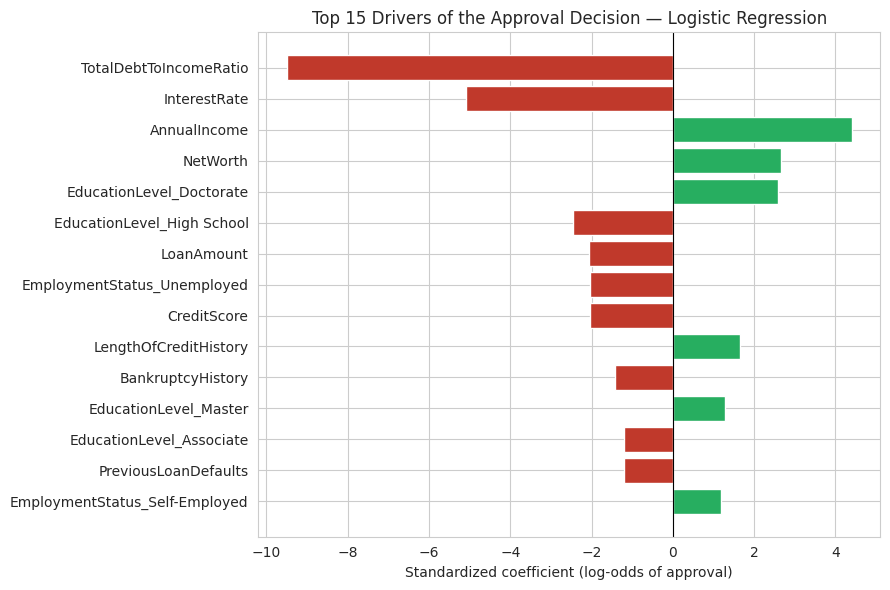

In [ ]:
feature_names = (NUM_COLS +
    list(best_pipe.named_steps['prep'].named_transformers_['cat'].named_steps['ohe']
         .get_feature_names_out(CAT_COLS)))

coefs = best_pipe.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefs})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#27ae60' if c > 0 else '#c0392b' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors)
ax.set_xlabel('Standardized coefficient (log-odds of approval)')
ax.set_title('Top 15 Drivers of the Approval Decision — Logistic Regression')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('imgs/feature_importance.png', bbox_inches='tight')
plt.show()


Green bars push toward **approval**, red bars push toward **denial**. The model's biggest levers
are financial fundamentals — income, debt-to-income ratio, interest rate, loan amount — which is
exactly the kind of transparent, defensible reasoning a regulator or loan officer needs to see, and
matches the directional patterns we already observed in the EDA.

### 5.5 Executive Summary & Conclusion

**What we built:** A logistic regression model that predicts loan approval from 29 applicant
attributes, with the decision threshold tuned to the business's actual cost structure rather than a
generic 0.5 cutoff.

**Why logistic regression:** It matched or slightly beat tuned Random Forest and XGBoost on both
ROC-AUC and PR-AUC, while remaining fully interpretable — each coefficient has a clear, auditable
meaning, which tree ensembles cannot offer as directly. In a regulated lending context, this
combination of top-tier performance *and* transparency is the ideal outcome.

**Business impact (test set):** Moving from a default 0.5 threshold to the cost-optimal threshold
further reduced total expected cost, and both comfortably beat naive "approve everyone" / "deny
everyone" policies — directly operationalizing the \$8,000 vs. \$50,000 asymmetry from Part 1.

**Key data-quality findings worth carrying into any production project:**
- `RiskScore` in this dataset is not usable as a feature — it is mathematically derived from the
  approval label and would leak the answer.
- Missingness is not always "random": `EducationLevel`'s missing values were a near-perfect proxy
  for denial and had to be imputed without a tell-tale indicator flag to avoid a fake performance
  boost that wouldn't survive contact with new data.
- `MonthlyIncome` and `AnnualIncome`/12 disagreed by as much as \$17,000 on some rows — a reporting
  inconsistency resolved by keeping one canonical income figure.

**Limitations & next steps before production:**
1. `LoanApproved` reflects **historical approval decisions**, not confirmed loan performance
   (actual default outcomes). If those decisions already embedded human bias or an imperfect
   process, the model will learn to reproduce it. A true "did this loan default" label — even on a
   held-out cohort of *approved* loans — would let us validate the cost assumptions directly rather
   than treating the historical decision as ground truth.
2. Fairness auditing across protected characteristics (proxies like age, marital status, employment
   status) should be run before deployment, given lending's legal scrutiny around disparate impact.
3. The cost-optimal threshold was tuned on this dataset's specific $8k/$50k figures; it should be
   revisited whenever the business's actual loss/profit assumptions change.
4. A live pilot with shadow-mode scoring (model recommends, human still decides) is a lower-risk way
   to validate real-world cost savings before full automation.
